# Phishing Email Detection Report

__Alumnos:__
- Carlos Berdaguer - a2605
- Lucas Campi - a2609

## __Introducción__

En la era moderna, el medio de comunicación más utilizado es el email, producto de ser un medio efectivo, rápido y barato. Según Kolmar (2019), 333.2 billones de mails son enviados a diario, lo que significa que el uso de mails es alto y, en adición, es bastante probable recibir un correo spam, fraude o phishing *Machine Learning Algorithms for Phishing Email Detection de Yoga Shri Murti y Palanichamy Naveen*

En el estudio *Building an Intelligent Phishing Email Detection System Using Machine 
Learning and Feature Engineering*, realizado por ingenieros de Microsoft, Code Ace, JP Morgan, Deloitte y North Start Group, sostienen lo dicho por Murti y Naveen y agregan que se evidencia que hoy en día es el tipo de cyber-ataque más común y exitoso, empleando distintas técnicas para engañar a sus objetivos. Sostienen que la importancia de la detección de phishing ha adquirido una considerable atención, y que existen múltiples técnicas y herramientas para la detección de correos phishing.

*Sristhi Rawal, Bhuvan Rawala, Aakhila Shaheen y Shubham Malik* definen el phishing como un tipo lucrativo de fraude, donde los criminales engañan a los objetivos para obtener información confidencial a partir de falsas pretensiones. Los correos phishing tienden a convencer a los receptores de clickear links o descargar archivos adjuntos con el objetivo de obtener información confidencial como contraseñas, información de tarjetas de crédito, etc. Sostienen que son enviados miles de correos a diario, que solo un pequeño porcentaje cae en la trampa pero que los daños son grandes. Citan el caso real de Google en 2017, donde se realizó un ataque masivo a alrededor de 1 billon de usuarios de Gmail, donde los usuarios recibían un correo que los redirigía a "Google Docs" y estos tenían que darle permisos a una página falsa.

En conclusión, el phishing es un tipo de ataque de ingeniería social donde un emisor envía un correo con algún tipo de contenido que busca convencer al receptor de que ese correo es real y legítimo. Muchas veces, con links o documentos adjuntos combinados con un correo lo suficientemente convincente como para que el receptor sea engañado con alguna falsa pretención.

## __Motivación__

Durante nuestros primeros cursos, se ha nombrado a los casos de *detección de SPAM* o *detección de Emails* como un tipos de problemas clásicos en el mundo de Machine Learning. Decidimos adentrarnos un poco en esta temática y, luego de leer distintos papers, descubrimos que a día de hoy sigue siendo una problemática vigente y que si bien se han desarrollado múltiples algoritmos, técnicas y herramientas para la detección de estos correos maliciosos, también evoluciona el nivel de sofisticación de este tipo de correos.
Existen múltiples algoritmos de Machine Learning para tratar esta casuística; como Naive-Baye, Nearest Neighbour, Multi-Layer perceptron, Support Vector Machine, etc.

Todo esto nos interesó a indagar más sobre este tema y creemos que es una buena oportunidad para ver un caso de Machine Learning aplicado a una problemática de la vida real.


__Bibliografía:__
*Building an Intelligent Phishing Email Detection System Using Machine 
Learning and Feature Engineering (Rao Chinta, Moore, Karaka, Sakuru, Bodepudi, Maka)*

*Phishing Detection in E-mails using Machine Learning (Rawal & Rawal, Shaheen, Malik)*
*Machine Learning Algorithms for Phishing Email Detection (Murti, Naveen)*

*Phishing Email Detection Using Inputs From Artificial Intelligence (Milthun, Bartlett, Mirkovic, Freedman)*

https://www.cnbc.com/2017/05/04/gmail-google-hack-phishing-attack.html

### Descripción del dataset

| Variable      | Descripción                                                                      |
| ------------- | -------------------------------------------------------------------------------- |
| `Email Text`  | Contenido del mail                                                               |
| `Email Type`  | Es seguro o phishing                                                             |

In [38]:
from aux import clean_email_text
from aux import plot_distribution
from aux import plot_histograma
from collections import Counter
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from scipy.sparse import save_npz
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import nltk
import numpy as np
import os
import pandas as pd
import re
import seaborn as sns

In [39]:
email_df = pd.read_csv('./datasets/Phishing_Email.csv')

Procederemos a hacer un breve análisis sobre el dataset:

In [40]:
email_df.nunique()

Unnamed: 0    18650
Email Text    17537
Email Type        2
dtype: int64

--------------
### Tratamiento de valores nulos
Podemos observar que solo hay dos tipos de mail: legítimo o phishing. Luego, la variable Email Text no está completa, es decir, se tomaron observaciones que se sabe que son phishing o no pero sin registrar el correo. Para nuestro análisis particular, no tiene sentido contener estos vacíos así que vamos a eliminarlos, además, vamos a mapear la variable Email Type como una variable categórica nominal binaria para facilitar la interpretabilidad (1 = Es phishing, 0 = no lo es).

No hacemos imputación para los vacíos ya que estaríamos introduciendo información sin tener certeza nosotros de QUÉ ES y QUÉ NO ES phishing.

In [41]:
email_df = email_df.dropna()
email_df["label"] = email_df["Email Type"].apply(lambda x: 1 if x == "Phishing Email" else 0)
email_df.drop(columns=['Unnamed: 0', 'Email Type'], inplace=True)
column_duplicates = email_df['Email Text'].duplicated().sum()
column_duplicates

np.int64(1097)

--------------

### Tratamiento de duplicados
Se observa que del total de mails, 1112 observaciones es el mismo correo; vamos a analizarlos para ver qué tratamiento se le da a duplicados.

In [42]:
duplicate_rows = email_df[email_df['Email Text'].duplicated()]
duplicate_rows

,Email Text,label
106,empty,0
130,empty,1
244,empty,1
305,empty,1
335,empty,1
...,...,...
18607,empty,0
18626,empty,0
18637,empty,1
18643,empty,0


Detectamos que el dataset contiene observaciones donde el campo "Email Text" contiene "empty" como texto haciendo alusión de que el mail estaba vacío y el valor del label tampoco coincide, por lo que vamos a remover los duplicados y los "empty".

In [43]:
email_df = email_df.drop_duplicates(subset=['Email Text'], keep='first')
email_df = email_df[email_df['Email Text'] != 'empty'] 

--------------

### Distribución por tipo de correo

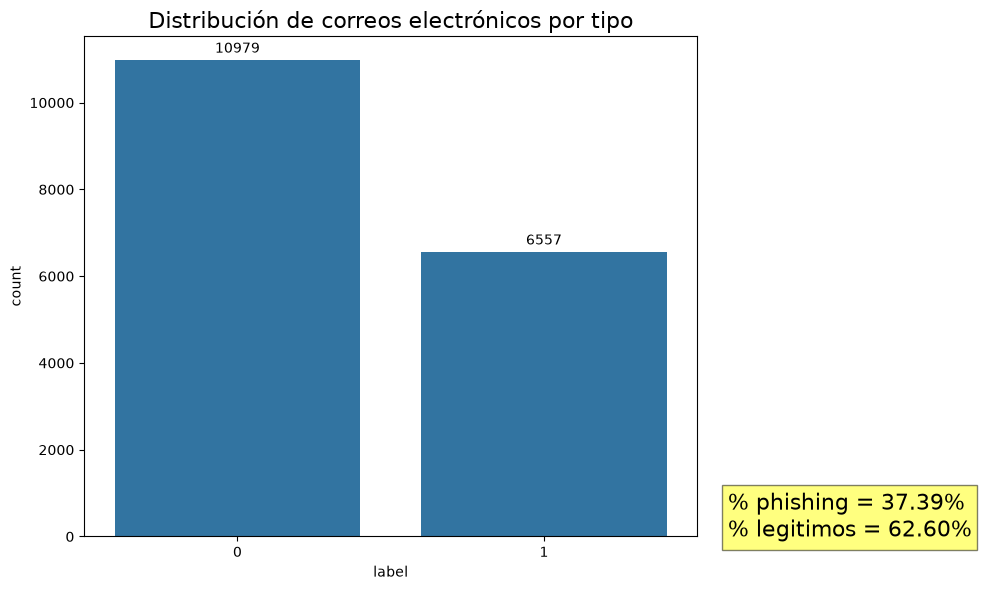

In [44]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='label', data=email_df)
ax.set_title('Distribución de correos electrónicos por tipo', fontsize=16)
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.text(1.6, 1, '% phishing = ' + str(email_df['label'].mean() * 100)[:5] + '% \n% legitimos = ' + str((1 - email_df['label'].mean()) * 100)[:5] + '%', fontsize=16, 
         bbox=dict(facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

Observamos que del dataset inicial, poco menos del 38% fue reportado como phishing.

Para darle más profundidad al análisis, agregaremos dos columnas en nuestro dataset; `has_link`, `words_count`.

In [45]:
email_df["word_count"] = email_df["Email Text"].apply(lambda x: len(x.split()))
email_df["has_link"] = email_df["Email Text"].apply(lambda x: 1 if "http" in x else 0)

Ahora observemos cuál es la proporción de mails que es phishing según si tiene o no link.

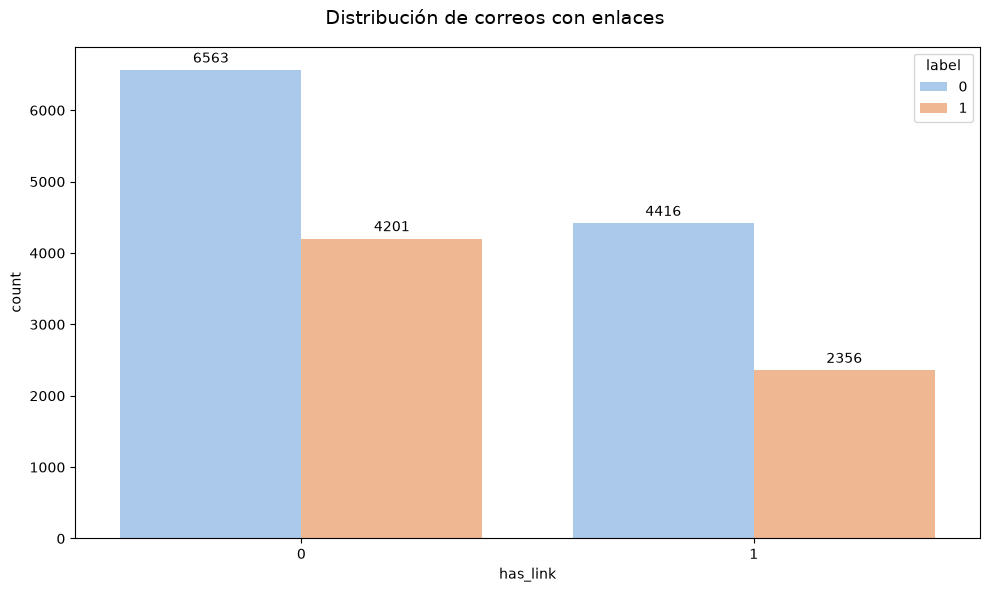

In [46]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(x='has_link', data=email_df, hue="label", palette='pastel')

plt.suptitle('Distribución de correos con enlaces', fontsize=14)
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)
    
plt.tight_layout()
plt.show()

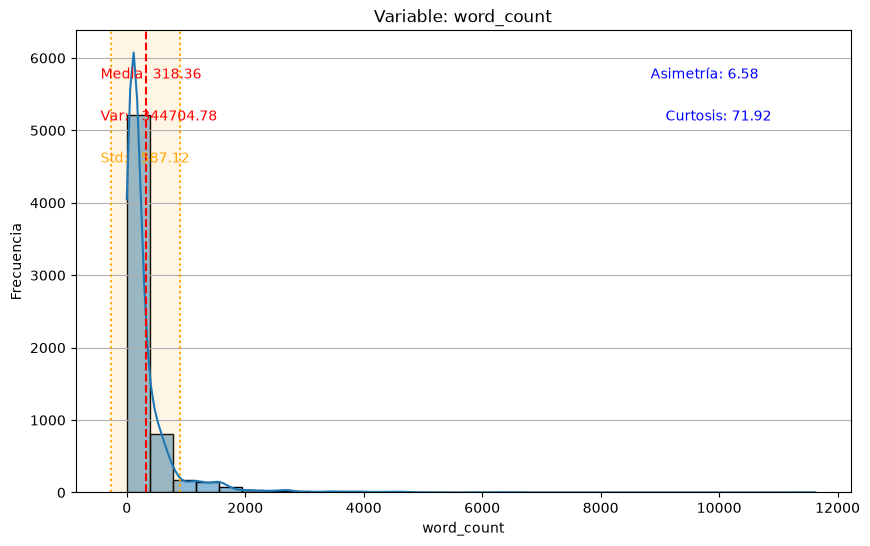

In [47]:
plot_histograma(email_df[email_df['label'] == 1], 'word_count', figsize=(10, 6), bins=30, kde=True, mvd=True, shade=True, snk=True) 

Se puede observar que hay outliers con cantidades descomunales de palabras. Vamos a filtrar utilizando el límite superior calculado a partir del rango intercuartil para poder hacer un mejor análisis de los correos.

--------------
### Split del dataset

Previa a cualquier transformación, procedemos a realizar el spliteo del dataset en un 80-20, consistente con la empleada por Murti & Naveen (2023) y por Chinta et al. (2025) en sus respectivos trabajos de referencia. Además, aplicamos un stratify para garantizar el balance de clases en ambos sets. Al set de entrenamiento le realizaremos las transformaciones necesarias para poder realizar, luego, el entrenamiento de los distintos modelos

In [48]:
y = email_df['label']
X = email_df.drop('label', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

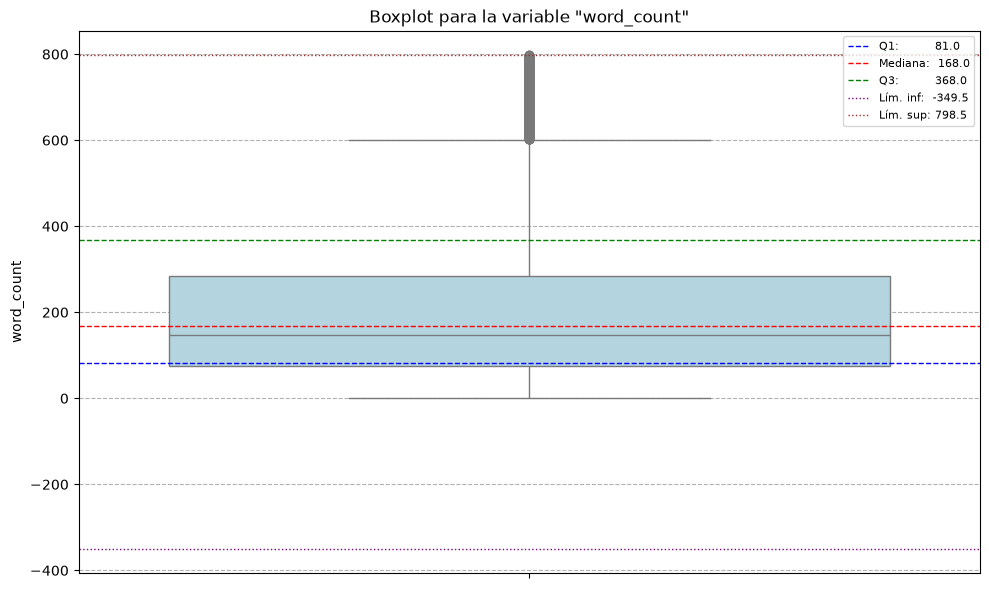

In [49]:

plt.figure(figsize=(10, 6))

word_count = X_train['word_count']

word_count_Q1 = word_count.quantile(0.25)
word_count_Q2 = word_count.quantile(0.50)
word_count_Q3 = word_count.quantile(0.75)
word_count_IQR = word_count_Q3 - word_count_Q1
lower_limit = word_count_Q1 - 1.5 * word_count_IQR
upper_limit = word_count_Q3 + 1.5 * word_count_IQR

train_mask = (X_train['word_count'] <= upper_limit) & (X_train['word_count'] >= lower_limit)
X_train, y_train = X_train[train_mask], y_train[train_mask]

test_mask = (X_test['word_count'] <= upper_limit) & (X_test['word_count'] >= lower_limit)
X_test, y_test = X_test[test_mask], y_test[test_mask]

ax = sns.boxplot(data=X_train, y='word_count', color="lightblue")
ax.axhline(word_count_Q1,      color='blue',   linestyle='--', linewidth=1, label=f'Q1:         {word_count_Q1:.1f}')
ax.axhline(word_count_Q2,      color='red',    linestyle='--', linewidth=1, label=f'Mediana:  {word_count_Q2:.1f}')
ax.axhline(word_count_Q3,      color='green',  linestyle='--', linewidth=1, label=f'Q3:         {word_count_Q3:.1f}')
ax.axhline(lower_limit, color='purple', linestyle=':',  linewidth=1, label=f'Lím. inf:  {lower_limit:.1f}')
ax.axhline(upper_limit, color='brown',  linestyle=':',  linewidth=1, label=f'Lím. sup: {upper_limit:.1f}')
ax.set_title('Boxplot para la variable "word_count"')
ax.legend(fontsize=8)
ax.grid(axis='y', ls='--')

plt.tight_layout()
plt.show()


Vamos a utilizar los cuartiles calculados para categorizar la variable words_count en tres

In [50]:
X_train

,Email Text,word_count,has_link
7626,"re : rtp conference hill , yes , i think it ca...",251,1
3858,nom / actual flow vols we agree - - - - - - - ...,144,0
10581,"re : account # 88288 m hello , we sent you an ...",101,1
4424,version diplomado gestion en comercio exterior...,141,0
15794,best very young preteens : - ) hi bro ! ; - ) ...,93,1
...,...,...,...
9097,start date : 1 / 8 / 02 ; hourahead hour : 8 ;...,63,0
12580,\n>>> Skip Montanaro wrote\n> \n> I actually l...,112,0
16420,With regards toWant to refinance?Fill out this...,55,1
6730,slavic languages 3rd european conference on fo...,364,1


In [51]:
def categorize_words(x):
    if x < word_count_Q1:
        return 'bajo'
    elif x < word_count_Q3:
        return 'medio'
    else:
        return 'largo'

X_train["words_count_cat"] = X_train["word_count"].apply(categorize_words)
X_test["words_count_cat"] = X_test["word_count"].apply(categorize_words)

X_train.value_counts('words_count_cat')

words_count_cat
medio    7025
bajo     3495
largo    2214
Name: count, dtype: int64

Ahora tenemos un mejor panorama, vamos a proceder a hacer el análisis de cantidad de palabras para aquellos correos con phishing y sin phishing

In [52]:
train_plot_df = X_train.copy()
train_plot_df['label'] = y_train

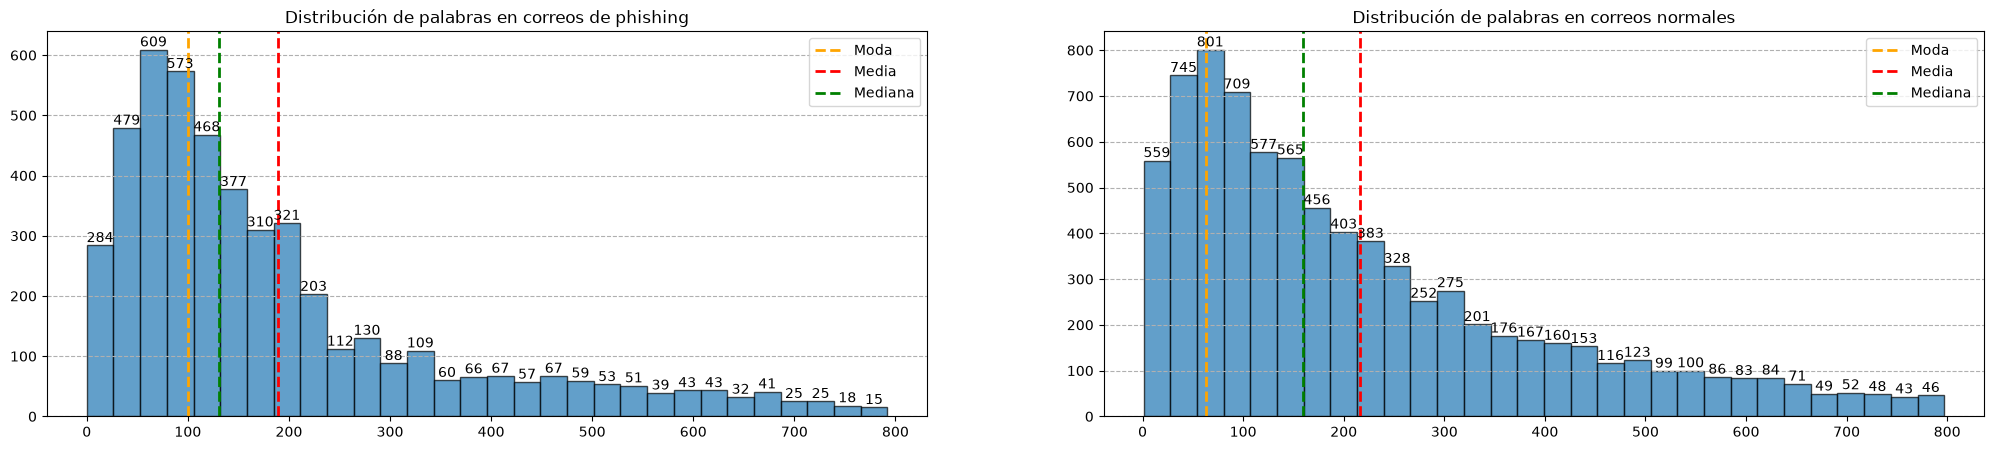

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(25, 5))

plot_distribution(axes[0], train_plot_df[train_plot_df['label'] == 1]['word_count'], 'Distribución de palabras en correos de phishing')
plot_distribution(axes[1], train_plot_df[train_plot_df['label'] == 0]['word_count'], 'Distribución de palabras en correos normales')

Se puede observar que la cantidad de palabras no es un factor influyente para determinar si un correo es o no phishing, de hecho, las distribuciones nos dicen que los correos identificados como normales tienen mayor cantidad de palabras en la mediana.

Fijémonos ahora según la categoría de la cantidad de palabras.

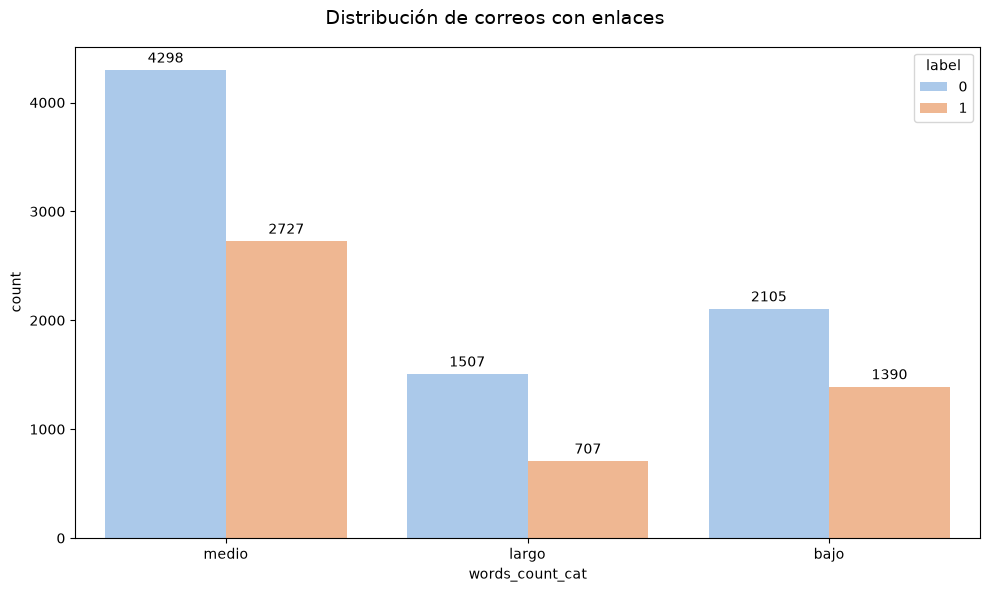

In [54]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(x='words_count_cat', data=train_plot_df, hue="label", palette='pastel')

plt.suptitle('Distribución de correos con enlaces', fontsize=14)
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)
    
    
plt.tight_layout()
plt.show()


Podemos observar que los correos con mayor cantidad de palabras, tienden a, en proporción, ser menos propensos a phishing. Luego, para los correos medio y bajo, si bien la mayoría de casos no es phishing, más de la mitad si lo es, siendo los de categoría "medio" aquellos más propensos a ser phishing.

--------------

### Limpieza de datos

In [55]:
all_text = " ".join(email_df['Email Text'].astype(str))
words = re.findall(r'\b\w+\b', all_text)
word_counts = Counter(words)
total_words = len(words)
print(f"Total number of words: {total_words}\n")
most_common = word_counts.most_common(10)
print("Most common words:")
for word, frequency in most_common:
    print(f"'{word}': {frequency} times")

Total number of words: 7934179

Most common words:
'the': 288658 times
'_': 234027 times
'of': 184049 times
'to': 174700 times
'and': 165407 times
'a': 121622 times
'in': 113764 times
'for': 79180 times
'is': 72634 times
'you': 66557 times


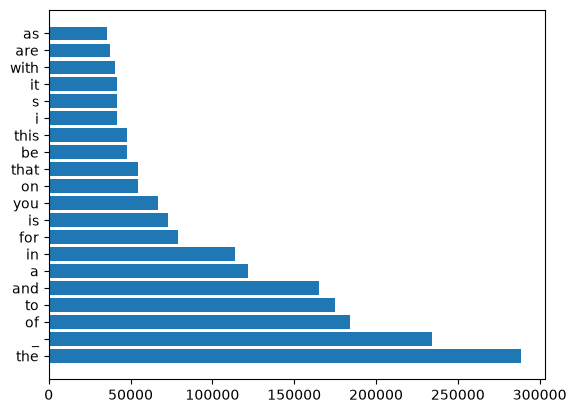

In [56]:
common_words, counts = zip(*word_counts.most_common(20))
plt.barh(common_words, counts)
plt.show()

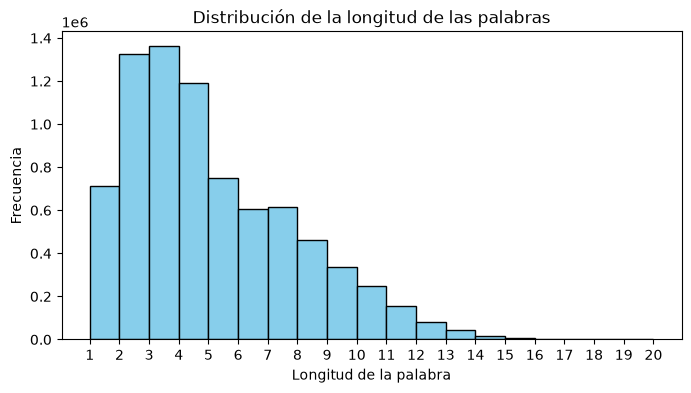

In [57]:
word_lengths = [len(word) for word in words]

plt.figure(figsize=(8, 4))
plt.hist(word_lengths, bins=range(1, 21), edgecolor='black', color='skyblue')
plt.title("Distribución de la longitud de las palabras")
plt.xlabel("Longitud de la palabra")
plt.ylabel("Frecuencia")
plt.xticks(range(1, 21))
plt.show()

* Se convierte todo a minúsculas para normalizar.
* Se remueven tags de markup que no contribuyen al análisis de texto.
* Se remueve puntuación para evitar que "¡hola!" sea considerado diferente que "hola".
* Se remueven dígitos para reducir ruido en el aprendizaje de patrones lingüísticos.
* Se remueven _stop words_ que no aportan a la clasificación.
* Se tokenizan las palabras para reducirlas a sus términos raíz.

In [58]:
nltk.data.path.append('nltk_data')
nltk.download('stopwords', 'nltk_data')
nltk.download('punkt_tab', 'nltk_data')

[nltk_data] Downloading package stopwords to nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [59]:
X_train['Email Text Raw'] = X_train['Email Text'].copy()
X_train['Email Text'] = X_train['Email Text'].apply(clean_email_text)
X_train.dropna(subset=['Email Text'], inplace=True)
X_train.drop_duplicates(subset=['Email Text'], keep='first', inplace=True)
y_train = y_train.loc[X_train.index]

X_test['Email Text Raw'] = X_test['Email Text'].copy()
X_test['Email Text'] = X_test['Email Text'].apply(clean_email_text)
X_test.dropna(subset=['Email Text'], inplace=True)
y_test = y_test.loc[X_test.index]

In [60]:
all_text = " ".join(X_train['Email Text'].astype(str))
words = re.findall(r'\b\w+\b', all_text)
word_counts = Counter(words)
total_words = len(words)
print(f"Total number of words: {total_words}\n")
most_common = word_counts.most_common(10)
print("Most common words:")
for word, frequency in most_common:
    print(f"'{word}': {frequency} times")

Total number of words: 1226552

Most common words:
'enron': 6387 times
'ect': 5594 times
'please': 5495 times
'email': 5017 times
'com': 4254 times
'one': 3962 times
'would': 3898 times
'get': 3773 times
'list': 3622 times
'new': 3570 times


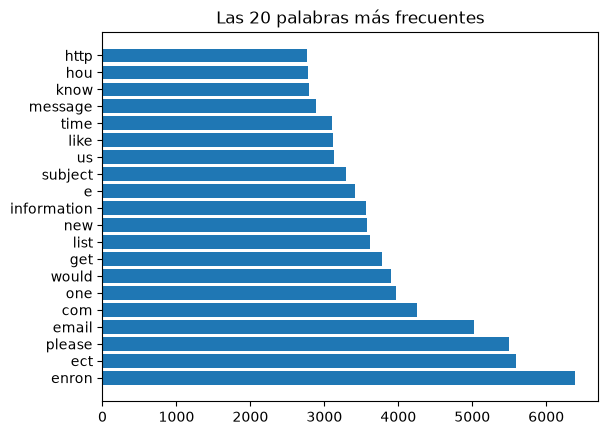

In [61]:
common_words, counts = zip(*word_counts.most_common(20))
plt.barh(common_words, counts)
plt.title("Las 20 palabras más frecuentes")
plt.show()

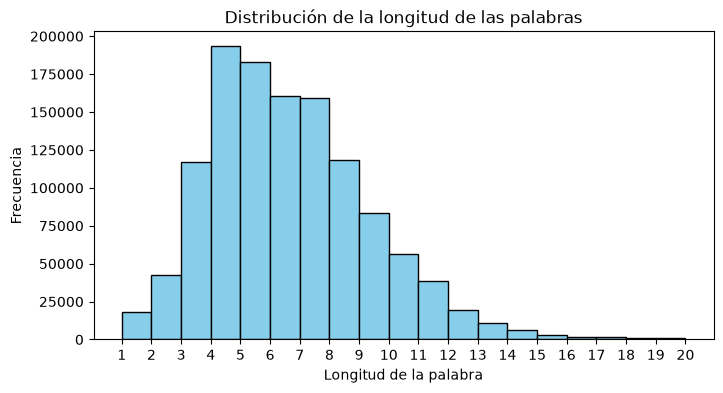

In [62]:
word_lengths = [len(word) for word in words]

plt.figure(figsize=(8, 4))
plt.hist(word_lengths, bins=range(1, 21), edgecolor='black', color='skyblue')
plt.title("Distribución de la longitud de las palabras")
plt.xlabel("Longitud de la palabra")
plt.ylabel("Frecuencia")
plt.xticks(range(1, 21))
plt.show()


In [63]:
X_train.drop(["word_count"], axis=1, inplace=True)
X_train_extra_features = X_train.drop('Email Text', axis=1)
X_train = X_train[['Email Text']]

X_test.drop(["word_count"], axis=1, inplace=True)
X_test_extra_features = X_test.drop('Email Text', axis=1)
X_test = X_test[['Email Text']]

--------------

### Vectorización TF-IDF

Para los algoritmos que aplicaremos, será necesario representar los features del dataset como variables numéricas. Por lo tanto, optamos por la técnica TF-IDF (Term Frequency - Inverse Document Frequency), que pondera la relevancia de cada término en función de su frecuencia relativa, penalizando palabras más cmunes. Además, esta técnica es la empleada como base por Murti & Naveen (2023).
El hiperparámetro de 5000 acota la dimensionalidad del vocabulario permite mantener la eficiencia computacional sin comprometer la pérdida de información

In [64]:
tfidf = TfidfVectorizer(max_features=5000)

tfidf_preprocessor = ColumnTransformer(transformers=[
    ('text', tfidf, 'Email Text')
], remainder='drop')

X_train_proc = tfidf_preprocessor.fit_transform(X_train)
X_test_proc = tfidf_preprocessor.transform(X_test)

---
### Feature engineering
Se agregan los features más significativos recomendados en la bibliografía útiles para este tipo de algoritmos; se sugieren muchos más, pero también se sugiere que se use la menor cantidad de features extra para alcanzar la mejor eficiencia del modelo.

#### Cantidad de verbos imperativos
Cuenta la presencia de verbos directivos o de mando en el correo electrónico. En la bibliografía, los verbos específicos considerados son "click", "verify",
"submit", "download" y "update").

In [65]:
IMPERATIVE_VERBS = ['click', 'verify', 'submit', 'download', 'update']

def get_imperative_verb_count(text):
    return sum(text.lower().count(verb) for verb in IMPERATIVE_VERBS)

X_train_extra_features['imperative_verbs_count'] = X_train_extra_features['Email Text Raw'].apply(get_imperative_verb_count)
X_test_extra_features['imperative_verbs_count'] = X_test_extra_features['Email Text Raw'].apply(get_imperative_verb_count)

#### Complejidad en oraciones
Considera el número de conectores por oración. Se divide por el número total de oraciones, lo que permite medir cuántas oraciones subordinadas pueden aparecer en todo el texto.

In [66]:
LINKING_WORDS = ['and', 'but', 'or', 'because']

nltk.data.path.append('nltk_data')
nltk.download('punkt_tab', 'nltk_data')

def get_clause_density(text):
    sentence_count = len(sent_tokenize(text))
    if sentence_count == 0:
        return 0.0
    total_conjunctions = sum(text.lower().count(word) for word in LINKING_WORDS)
    complexity_ratio = total_conjunctions / sentence_count
    return complexity_ratio / sentence_count

X_train_extra_features['clause_density'] = X_train_extra_features['Email Text Raw'].apply(get_clause_density)
X_test_extra_features['clause_density'] = X_test_extra_features['Email Text Raw'].apply(get_clause_density)

[nltk_data] Downloading package punkt_tab to nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


#### Densidad de pronombres
Divide el número total de pronombres entre el número total de palabras.

In [67]:
TARGET_PRONOUNS = ['i', 'you', 'he', 'she', 'it', 'we', 'they']

def get_pronoun_density(text):
    tokens = word_tokenize(text.lower())
    total_words = len(tokens)
    if total_words == 0:
        return 0.0
    pronoun_count = sum(1 for word in tokens if word in TARGET_PRONOUNS)
    return pronoun_count / total_words

X_train_extra_features['pronoun_density'] = X_train_extra_features['Email Text Raw'].apply(get_pronoun_density)
X_test_extra_features['pronoun_density'] = X_test_extra_features['Email Text Raw'].apply(get_pronoun_density)

#### Cantidad de marcadores de urgencia

In [68]:
URGENCY_WORDS = ['urgent', 'asap', 'immediately', 'deadline']

def get_urgency_markers_count(text):
    return sum(text.lower().count(word) for word in URGENCY_WORDS)

X_train_extra_features['urgency_markers_count'] = X_train_extra_features['Email Text Raw'].apply(get_urgency_markers_count)
X_test_extra_features['urgency_markers_count'] = X_test_extra_features['Email Text Raw'].apply(get_urgency_markers_count)

#### Cantidad de puntos en dominios

In [69]:
DOT_COUNT_THRESHOLD = 3

def has_high_domain_dot_count(text):
    urls = re.findall(r'(https?://\S+)', text)
    for url in urls:
        if url.count('.') > DOT_COUNT_THRESHOLD:
            return 1
    return 0

X_train_extra_features['domain_dot_high'] = X_train_extra_features['Email Text Raw'].apply(has_high_domain_dot_count)
X_test_extra_features['domain_dot_high'] = X_test_extra_features['Email Text Raw'].apply(has_high_domain_dot_count)

#### Tags HTML sospechosos

In [70]:
def has_suspicious_tags(text):
    clean_text = text.lower()
    if '<script' in clean_text or '<form' in clean_text:
        return 1
    return 0

X_train_extra_features['has_suspicious_tags'] = X_train_extra_features['Email Text Raw'].apply(has_suspicious_tags)
X_test_extra_features['has_suspicious_tags'] = X_test_extra_features['Email Text Raw'].apply(has_suspicious_tags)

--------------

### Guardado de los datasets para entrenamiento y prueba

Haremos el guardado del dataset para que luego cada modelo pueda importar y entrenar, enfocándose así solo en la correcta configuración de hiperparámetros.

In [71]:
print(f"X_train_proc shape: {X_train_proc.shape}")
print(f"X_test_proc shape: {X_test_proc.shape}")
print(f"X_train_extra_features shape: {X_train_extra_features.shape}")
print(f"X_test_extra_features shape: {X_test_extra_features.shape}")

X_train_proc shape: (12464, 5000)
X_test_proc shape: (3186, 5000)
X_train_extra_features shape: (12464, 9)
X_test_extra_features shape: (3186, 9)


In [72]:
os.makedirs('datasets', exist_ok=True)

save_npz('datasets/X_train.npz', X_train_proc)
save_npz('datasets/X_test.npz', X_test_proc)

y_train.to_csv('datasets/y_train.csv', index=False)
y_test.to_csv('datasets/y_test.csv', index=False)

X_train_extra_features.to_csv('datasets/X_extra_train.csv', index=False)
X_test_extra_features.to_csv('datasets/X_extra_test.csv', index=False)